In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import numpy as np

The wide dense model, surprisingly, has better loss compared to the deep version with roughly same number of parameters. The wide dense model also exhibits more stable training, which is expected.

In [44]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [45]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [43]:
def train(model, criterion, optimizer):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    epochs = 10000
    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=20):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.initial = nn.Linear(n * 2, n)

        self.linears = nn.ModuleList()
        for i in range(num_layers):
            self.linears.append(nn.Linear(n * 2, n))

            with torch.no_grad():
                nn.init.zeros_(self.linears[i].weight) # type: ignore
                nn.init.zeros_(self.linears[i].bias)   # type: ignore

        self.final = nn.Linear(n, 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, og_x):
        x = og_x + self.bias

        pos = torch.clamp(x, max=0)
        neg = torch.clamp(x, min=0)
        
        x = self.initial(torch.cat([pos, neg], dim=-1)) + og_x

        for linear in self.linears:
            pos = torch.clamp(x, max=0)
            neg = torch.clamp(x, min=0)
        
            x = linear(torch.cat([pos, neg], dim=-1)) + x

        x = self.final(x)
        return torch.cat([x, -x], dim=-1)

In [17]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─Linear: 2-1                       [43152, 7]                105
│    └─ModuleList: 2-2                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 7]                105
│    │    └─Linear: 3-3                  [43152, 7]                105
│    │    └─Linear: 3-4                  [43152, 7]                105
│    │    └─Linear: 3-5                  [43152, 7]                105
│    │    └─Linear: 3-6                  [43152, 7]                105
│    │    └─Linear: 3-7                  [43152, 7]                105
│    │    └─Linear: 3-8                  [43152, 7]                105
│    │    └─Linear: 3-9                  [43152, 7]                105
│    │

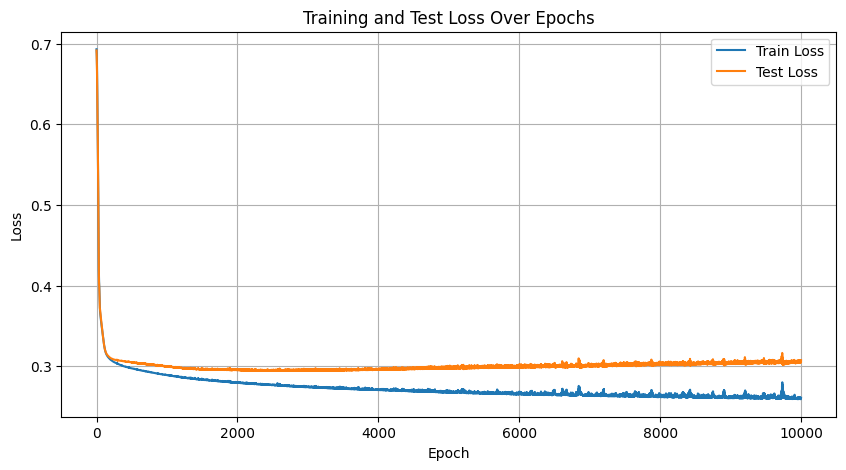

In [18]:
train(model, criterion, optimizer)

In [7]:
train(model, criterion, optimizer)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─Linear: 2-1                       [43152, 7]                105
│    └─ModuleList: 2-2                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 7]                105
│    │    └─Linear: 3-3                  [43152, 7]                105
│    │    └─Linear: 3-4                  [43152, 7]                105
│    │    └─Linear: 3-5                  [43152, 7]                105
│    │    └─Linear: 3-6                  [43152, 7]                105
│    │    └─Linear: 3-7                  [43152, 7]                105
│    │    └─Linear: 3-8                  [43152, 7]                105
│    │    └─Linear: 3-9                  [43152, 7]                105
│    │

In [46]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=3):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.linears = nn.ModuleList()
        for i in range(num_layers):
            dim = n * (2**i)
            self.linears.append(nn.Linear(dim * 2, dim))

            with torch.no_grad():
                self.linears[i].weight.copy_(torch.eye(dim).repeat_interleave(2, dim=1)) # type: ignore
                nn.init.zeros_(self.linears[i].bias) # type: ignore

        self.final = nn.Linear((2 * n) * (2**num_layers), 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        x = x + self.bias
        pos = torch.clamp(x, max=0)
        neg = torch.clamp(x, min=0)
        x = torch.cat([pos, neg], dim=-1)

        for linear in self.linears:
            out = linear(x)
            pos = torch.clamp(out, max=0)
            neg = torch.clamp(out, min=0)
            x = torch.cat([x, pos, neg], dim=-1)

        x = self.final(x)
        return torch.cat([x, -x], dim=-1)

In [47]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

W0517 22:34:20.618000 70291 torch/_dynamo/convert_frame.py:906] [5/56] torch._dynamo hit config.cache_size_limit (16)
W0517 22:34:20.618000 70291 torch/_dynamo/convert_frame.py:906] [5/56]    function: 'hook' (/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/torchinfo/torchinfo.py:592)
W0517 22:34:20.618000 70291 torch/_dynamo/convert_frame.py:906] [5/56]    last reason: 5/30: Cache line invalidated because L['module'] got deallocated
W0517 22:34:20.618000 70291 torch/_dynamo/convert_frame.py:906] [5/56] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0517 22:34:20.618000 70291 torch/_dynamo/convert_frame.py:906] [5/56] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    │    └─Linear: 3-3                  [43152, 28]               1,596
│    └─Linear: 2-2                       [43152, 1]                113
Total params: 2,227
Trainable params: 2,227
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 95.80
Input size (MB): 1.21
Forward/backward pass size (MB): 17.26
Params size (MB): 0.01
Estimated Total Size (MB): 18.48
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

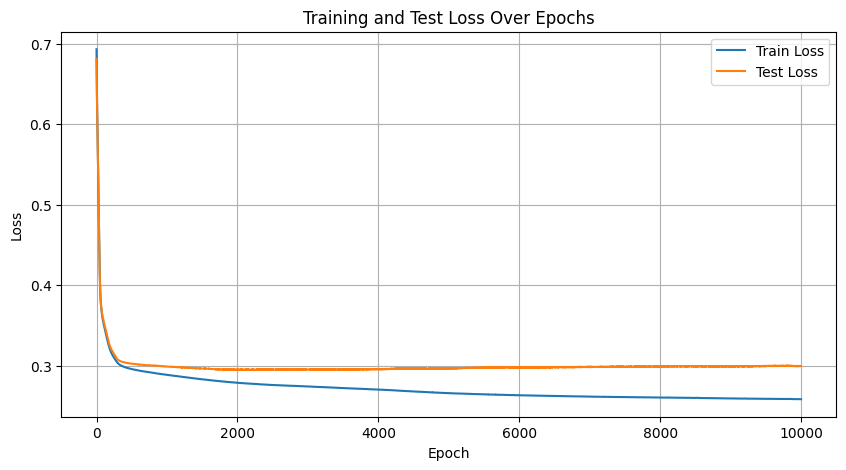

In [48]:
train(model, criterion, optimizer)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    │    └─Linear: 3-3                  [43152, 28]               1,596
│    └─Linear: 2-2                       [43152, 1]                113
Total params: 2,227
Trainable params: 2,227
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 95.80
Input size (MB): 1.21
Forward/backward pass size (MB): 17.26
Params size (MB): 0.01
Estimated Total Size (MB): 18.48
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.2584,  0.2047,  0.0859,  0.1631,  0.2058,  0.1967

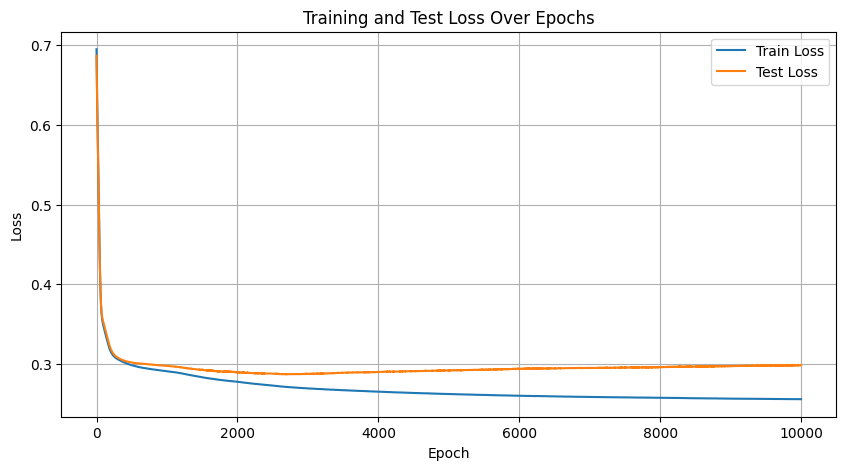

In [15]:
train(model, criterion, optimizer)